# **Notebook 4: Distributed Model Evaluation & Business Insights**
**Input**: Trained models from `data/models/` | Test split from `data/features_parquet/test/`

## **1. SparkSession & Load Models**

In [1]:
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark import StorageLevel
from pyspark.ml.classification import (
    LogisticRegressionModel,
    RandomForestClassificationModel,
    GBTClassificationModel,
    LinearSVCModel,
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)

spark = (
    SparkSession.builder
    .appName("HDFS_Anomaly_Evaluation")
    .config("spark.driver.memory", "6g")
    .config("spark.executor.memory", "6g")
    .config("spark.sql.shuffle.partitions", "100")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .master("local[*]")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

BASE_DIR   = "/home/sayan/Lakhveer"
FEAT_DIR   = os.path.join(BASE_DIR, "project", "data", "features_parquet")
MODELS_DIR = os.path.join(BASE_DIR, "project", "data", "models")
OUT_DIR    = os.path.join(BASE_DIR, "project", "data", "samples")

lr_model  = LogisticRegressionModel.load(os.path.join(MODELS_DIR, "lr_model"))
rf_model  = RandomForestClassificationModel.load(os.path.join(MODELS_DIR, "rf_model"))
gbt_model = GBTClassificationModel.load(os.path.join(MODELS_DIR, "gbt_model"))
svc_model = LinearSVCModel.load(os.path.join(MODELS_DIR, "svc_model"))
print("All MLlib models loaded.")

train_df = spark.read.parquet(os.path.join(FEAT_DIR, "train"))
test_df  = spark.read.parquet(os.path.join(FEAT_DIR, "test")).persist(StorageLevel.MEMORY_AND_DISK)
n_test   = test_df.count()
print(f"Test rows: {n_test:,}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/01 10:50:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


All MLlib models loaded.


Test rows: 689,195


## **2. Test-Set Predictions**

In [2]:
LABEL_COL = "Label"
STD_FEAT  = "std_features"
RAW_FEAT  = "raw_features"

bin_eval  = BinaryClassificationEvaluator(labelCol=LABEL_COL, rawPredictionCol='rawPrediction')
mc_f1     = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol='prediction', metricName='f1')
mc_acc    = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol='prediction', metricName='accuracy')
mc_prec   = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol='prediction', metricName='weightedPrecision')
mc_rec    = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol='prediction', metricName='weightedRecall')

model_specs = [
    ('Logistic Regression', lr_model,  STD_FEAT),
    ('Random Forest',       rf_model,  RAW_FEAT),
    ('GBT',                 gbt_model, RAW_FEAT),
    ('Linear SVC',          svc_model, STD_FEAT),
]

test_results = {}
pred_dfs     = {}

for name, model, feat_col in model_specs:
    pred = model.transform(test_df)
    pred_dfs[name] = pred
    auc  = bin_eval.evaluate(pred)
    f1   = mc_f1.evaluate(pred)
    acc  = mc_acc.evaluate(pred)
    prec = mc_prec.evaluate(pred)
    rec  = mc_rec.evaluate(pred)
    test_results[name] = {
        'AUC_ROC'  : round(auc,  4),
        'F1'       : round(f1,   4),
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
    }
    print(f"{name:22s}  AUC={auc:.4f}  F1={f1:.4f}  Acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}")

26/03/01 10:50:23 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/01 10:50:23 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/03/01 10:50:32 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


Logistic Regression     AUC=0.9928  F1=0.9649  Acc=0.9562  P=0.9819  R=0.9562


26/03/01 10:50:39 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/03/01 10:50:47 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/03/01 10:50:54 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/03/01 10:51:01 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


Random Forest           AUC=0.9997  F1=0.9968  Acc=0.9969  P=0.9969  R=0.9969


GBT                     AUC=0.9996  F1=0.9982  Acc=0.9982  P=0.9982  R=0.9982


Linear SVC              AUC=0.9918  F1=0.9594  Acc=0.9481  P=0.9809  R=0.9481


## **3. Confusion Matrices**

26/03/01 10:51:27 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


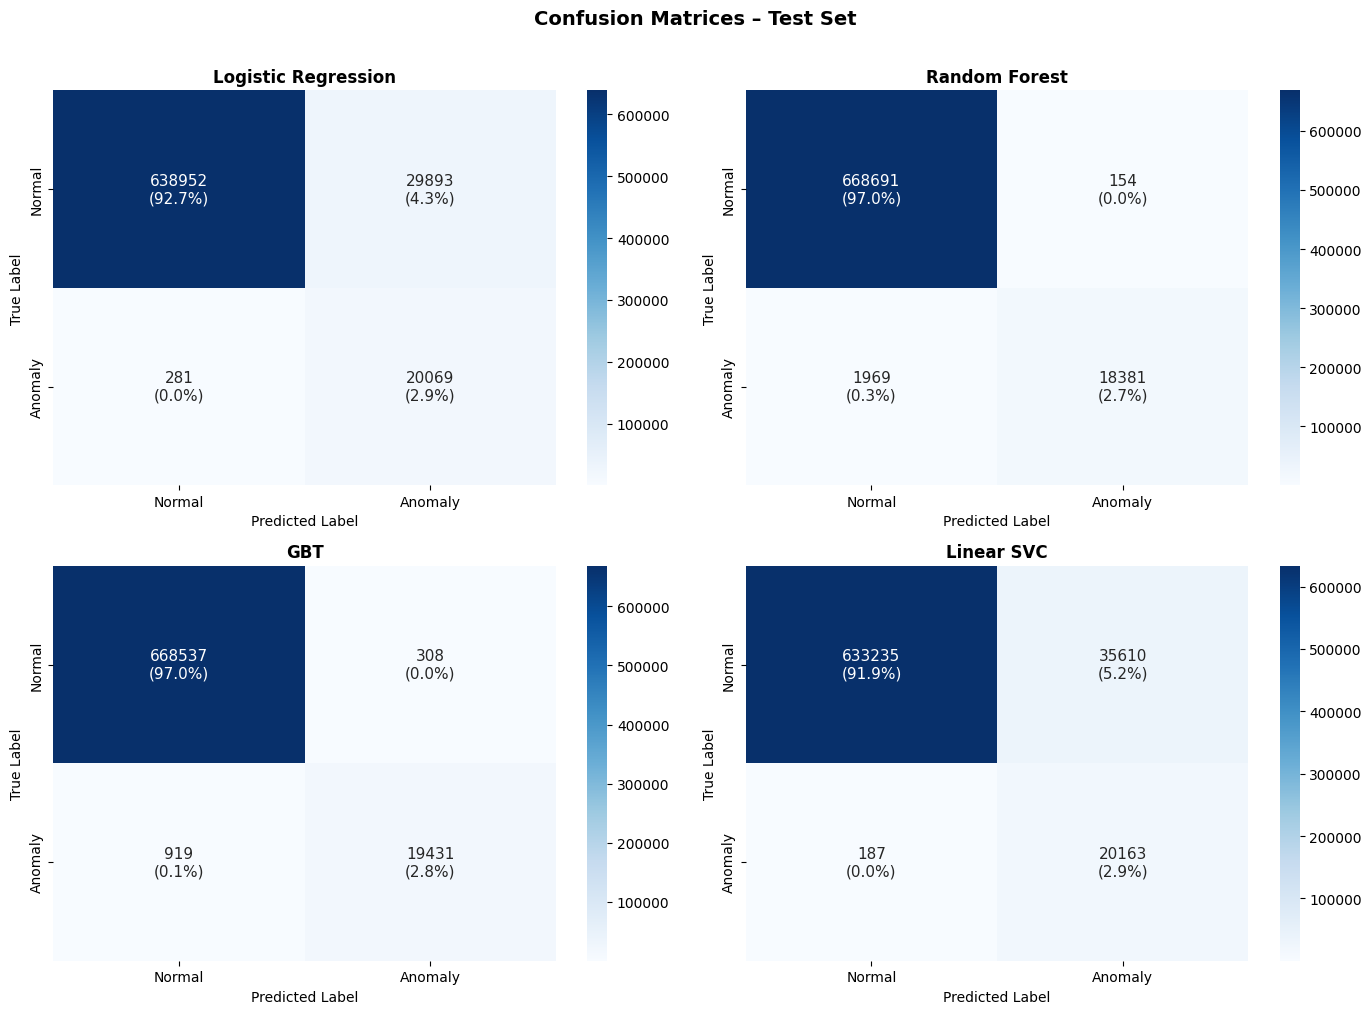

In [3]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, pred_df) in zip(axes.ravel(), pred_dfs.items()):
    pdf    = pred_df.select('Label', 'prediction').toPandas()
    y_true = pdf['Label'].astype(int)
    y_pred = pdf['prediction'].astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum() * 100
    labels = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
                        for row_v, row_p in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Normal','Anomaly'], yticklabels=['Normal','Anomaly'],
                annot_kws={'size': 11})
    ax.set_title(f"{name}", fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices – Test Set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'confusion_matrices.png'), bbox_inches='tight')
plt.show()

## **4. ROC Curves**

26/03/01 10:51:46 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


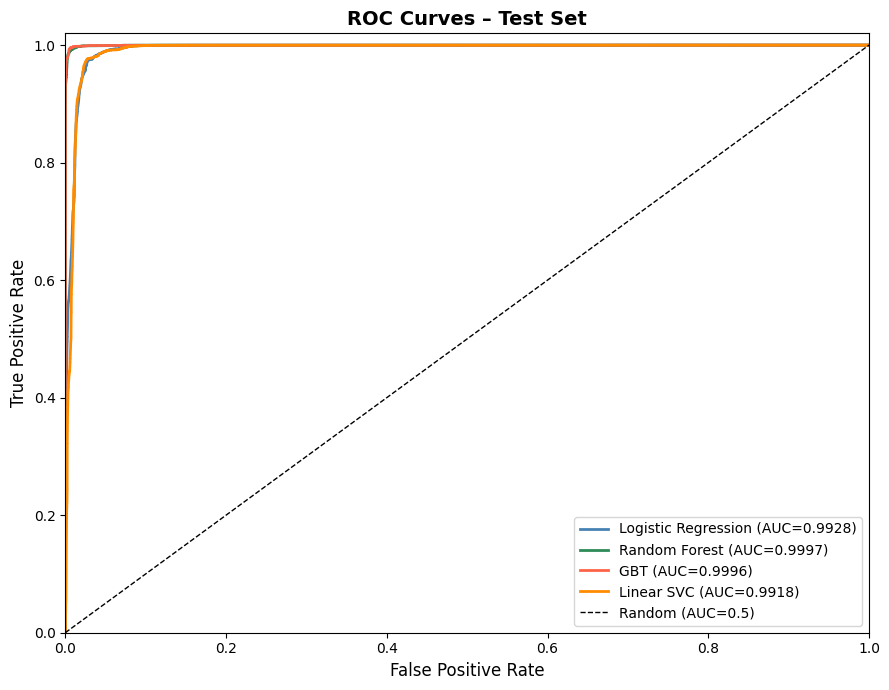

ROC data exported.


In [4]:
from sklearn.metrics import roc_curve, auc as sk_auc
from pyspark.ml.functions import vector_to_array

fig, ax = plt.subplots(figsize=(9, 7))
colors  = ['steelblue', 'seagreen', 'tomato', 'darkorange']
roc_export_rows = []

for color, (name, pred_df) in zip(colors, pred_dfs.items()):
    if 'probability' in pred_df.columns:
        pdf    = pred_df.withColumn('_s', vector_to_array('probability')[1]) \
                        .select('Label', '_s').toPandas()
    else:
        pdf    = pred_df.withColumn('_s', vector_to_array('rawPrediction')[1]) \
                        .select('Label', '_s').toPandas()

    y_true      = pdf['Label'].values
    scores      = pdf['_s'].values
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc     = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={roc_auc:.4f})")

    for fp_v, tp_v in zip(fpr[::50], tpr[::50]):
        roc_export_rows.append({'Model': name, 'FPR': fp_v, 'TPR': tp_v, 'AUC': roc_auc})

ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – Test Set', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'roc_curves.png'), bbox_inches='tight')
plt.show()

pd.DataFrame(roc_export_rows).to_csv(os.path.join(OUT_DIR, 'roc_data.csv'), index=False)
print("ROC data exported.")

## **5. Precision-Recall Curves**

26/03/01 10:52:05 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


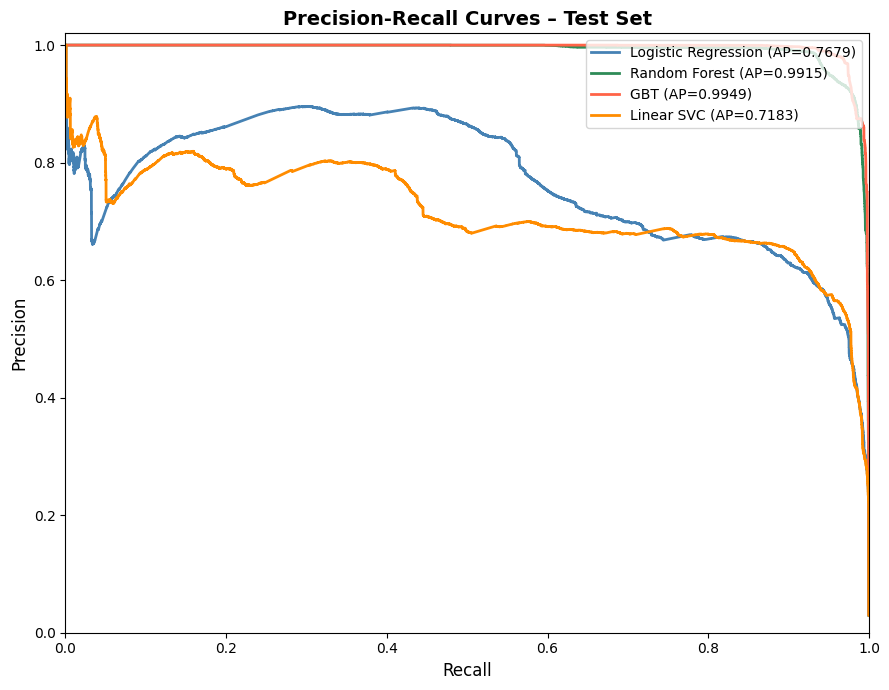

PR data exported.


In [5]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from pyspark.ml.functions import vector_to_array

fig, ax = plt.subplots(figsize=(9, 7))
pr_export_rows = []

for color, (name, pred_df) in zip(colors, pred_dfs.items()):
    if 'probability' in pred_df.columns:
        pdf = pred_df.withColumn('_s', vector_to_array('probability')[1]) \
                     .select('Label','_s').toPandas()
    else:
        pdf = pred_df.withColumn('_s', vector_to_array('rawPrediction')[1]) \
                     .select('Label','_s').toPandas()

    y_true        = pdf['Label'].values
    scores        = pdf['_s'].values
    prec, rec, _  = precision_recall_curve(y_true, scores)
    ap            = average_precision_score(y_true, scores)
    ax.plot(rec, prec, color=color, lw=2, label=f"{name} (AP={ap:.4f})")

    for p_v, r_v in zip(prec[::50], rec[::50]):
        pr_export_rows.append({'Model': name, 'Precision': p_v, 'Recall': r_v, 'AP': ap})

ax.set_xlabel('Recall',    fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves – Test Set', fontweight='bold', fontsize=14)
ax.legend(loc='upper right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pr_curves.png'), bbox_inches='tight')
plt.show()

pd.DataFrame(pr_export_rows).to_csv(os.path.join(OUT_DIR, 'pr_data.csv'), index=False)
print("PR data exported.")

## **6. Bootstrap Confidence Intervals (F1 Score)**

Logistic Regression     F1=0.9649  95% CI=[0.9646, 0.9653]


26/03/01 10:52:59 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


Random Forest           F1=0.9968  95% CI=[0.9967, 0.9970]


GBT                     F1=0.9982  95% CI=[0.9981, 0.9983]


Linear SVC              F1=0.9594  95% CI=[0.9591, 0.9598]


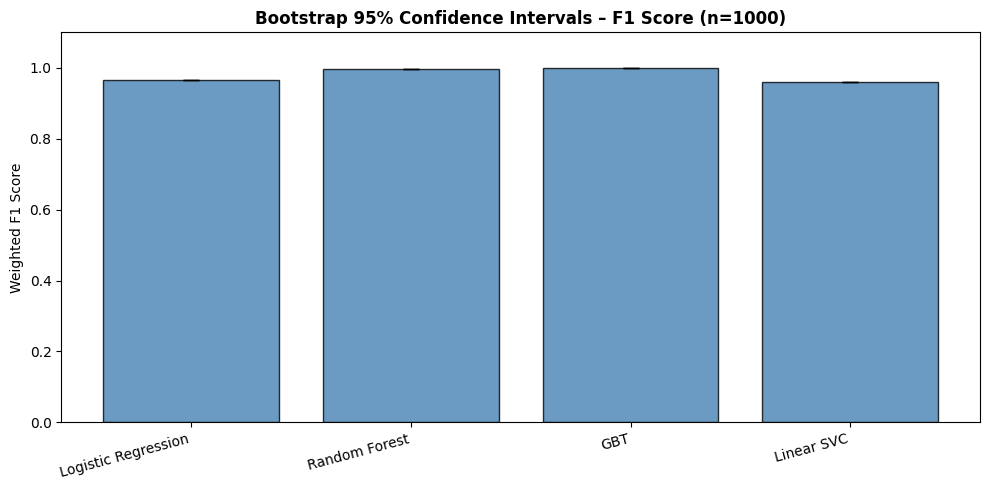

Bootstrap CI saved.


In [6]:
from sklearn.metrics import f1_score

N_BOOTSTRAP = 1000
ALPHA       = 0.05
ci_results  = {}

for name, pred_df in pred_dfs.items():
    pdf    = pred_df.select('Label', 'prediction').toPandas()
    y_true = pdf['Label'].values.astype(int)
    y_pred = pdf['prediction'].values.astype(int)
    n      = len(y_true)

    boot_f1 = []
    rng = np.random.default_rng(42)
    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, n, size=n)
        boot_f1.append(f1_score(y_true[idx], y_pred[idx], average='weighted', zero_division=0))

    lo, hi = np.percentile(boot_f1, [100*ALPHA/2, 100*(1-ALPHA/2)])
    ci_results[name] = {
        'mean_f1' : round(np.mean(boot_f1), 4),
        'ci_lower': round(lo, 4),
        'ci_upper': round(hi, 4),
    }
    print(f"{name:22s}  F1={np.mean(boot_f1):.4f}  95% CI=[{lo:.4f}, {hi:.4f}]")

ci_df = pd.DataFrame(ci_results).T.reset_index()
ci_df.columns = ['Model','mean_f1','ci_lower','ci_upper']
ci_df[['mean_f1','ci_lower','ci_upper']] = ci_df[['mean_f1','ci_lower','ci_upper']].astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ci_df))
ax.bar(x, ci_df['mean_f1'], color='steelblue', alpha=0.8, edgecolor='black')
ax.errorbar(x, ci_df['mean_f1'],
            yerr=[(ci_df['mean_f1']-ci_df['ci_lower']).values,
                  (ci_df['ci_upper']-ci_df['mean_f1']).values],
            fmt='none', color='black', capsize=6, linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(ci_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Weighted F1 Score')
ax.set_title(f'Bootstrap 95% Confidence Intervals – F1 Score (n={N_BOOTSTRAP})', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'bootstrap_ci.png'), bbox_inches='tight')
plt.show()

ci_df.to_csv(os.path.join(OUT_DIR, 'bootstrap_ci.csv'), index=False)
print("Bootstrap CI saved.")

## **7. Stratified Cross-Validation – GBT (5-Fold)**

In [7]:
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

gbt_cv = GBTClassifier(
    featuresCol="raw_features", labelCol=LABEL_COL,
    maxIter=30, maxDepth=5, stepSize=0.1, seed=42,
)
param_single = ParamGridBuilder().build()

cv5 = CrossValidator(
    estimator          = gbt_cv,
    estimatorParamMaps = param_single,
    evaluator          = BinaryClassificationEvaluator(labelCol=LABEL_COL),
    numFolds           = 5,
    parallelism        = 2,
    seed               = 42,
    collectSubModels   = False,
)

t0        = time.time()
cv5_model = cv5.fit(train_df)
print(f"5-fold CV done in {time.time()-t0:.1f}s")
print(f"GBT 5-fold CV AUC scores : {[round(s,4) for s in cv5_model.avgMetrics]}")
print(f"Mean: {np.mean(cv5_model.avgMetrics):.4f}  Std: {np.std(cv5_model.avgMetrics):.4f}")

5-fold CV done in 487.8s
GBT 5-fold CV AUC scores : [np.float64(0.9988)]
Mean: 0.9988  Std: 0.0000


## **8. Business Metrics – Anomaly Detection Value**

Logistic Regression     TP= 20,069  FP= 29,893  FN=    281  Value=$     7,977,850


26/03/01 11:02:49 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


Random Forest           TP= 18,381  FP=    154  FN=  1,969  Value=$     5,244,800


GBT                     TP= 19,431  FP=    308  FN=    919  Value=$     7,862,100
Linear SVC              TP= 20,163  FP= 35,610  FN=    187  Value=$     7,927,000


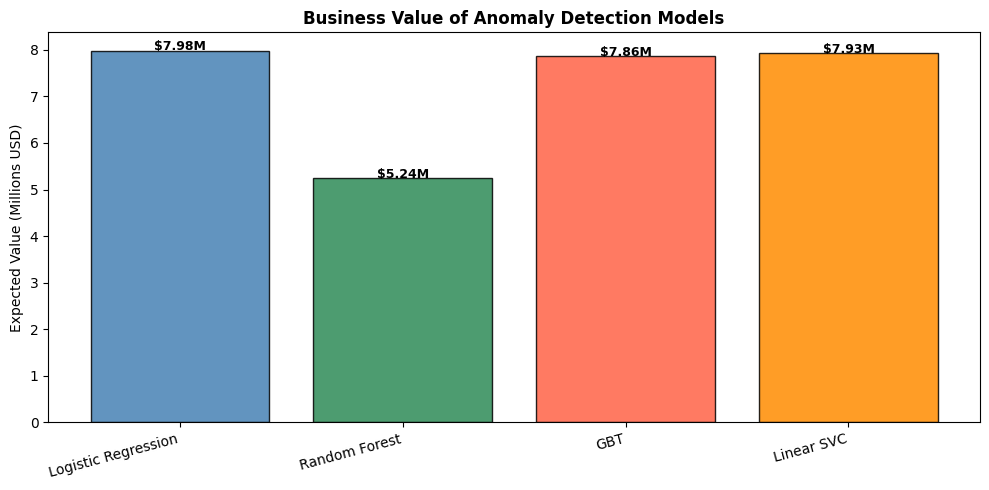

In [8]:
from sklearn.metrics import confusion_matrix

COST_TP =  500
COST_FP = -50
COST_FN = -2000
COST_TN =  0

biz_rows = []
for name, pred_df in pred_dfs.items():
    pdf    = pred_df.select('Label','prediction').toPandas()
    y_true = pdf['Label'].astype(int).values
    y_pred = pdf['prediction'].astype(int).values
    cm     = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_value = tp*COST_TP + fp*COST_FP + fn*COST_FN + tn*COST_TN
    biz_rows.append({
        'Model'           : name,
        'TP'              : int(tp),
        'FP'              : int(fp),
        'FN'              : int(fn),
        'TN'              : int(tn),
        'Total_Value_USD' : int(total_value),
    })
    print(f"{name:22s}  TP={tp:>7,}  FP={fp:>7,}  FN={fn:>7,}  Value=${total_value:>14,}")

biz_df = pd.DataFrame(biz_rows)
biz_df.to_csv(os.path.join(OUT_DIR, 'business_metrics.csv'), index=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(biz_df['Model'], biz_df['Total_Value_USD']/1e6,
              color=['steelblue','seagreen','tomato','darkorange'],
              edgecolor='black', alpha=0.85)
ax.set_ylabel('Expected Value (Millions USD)')
ax.set_title('Business Value of Anomaly Detection Models', fontweight='bold')
ax.set_xticklabels(biz_df['Model'], rotation=15, ha='right')
for bar, val in zip(bars, biz_df['Total_Value_USD']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"${val/1e6:.2f}M", ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'business_value.png'), bbox_inches='tight')
plt.show()

## **9. Learning Curves**

Learning curves – Logistic Regression:


  frac=0.1  train_F1=0.9827  val_F1=0.9822


  frac=0.2  train_F1=0.9823  val_F1=0.9822


  frac=0.4  train_F1=0.9824  val_F1=0.9823


  frac=0.6  train_F1=0.9824  val_F1=0.9822


  frac=0.8  train_F1=0.9824  val_F1=0.9823


  frac=1.0  train_F1=0.9824  val_F1=0.9823


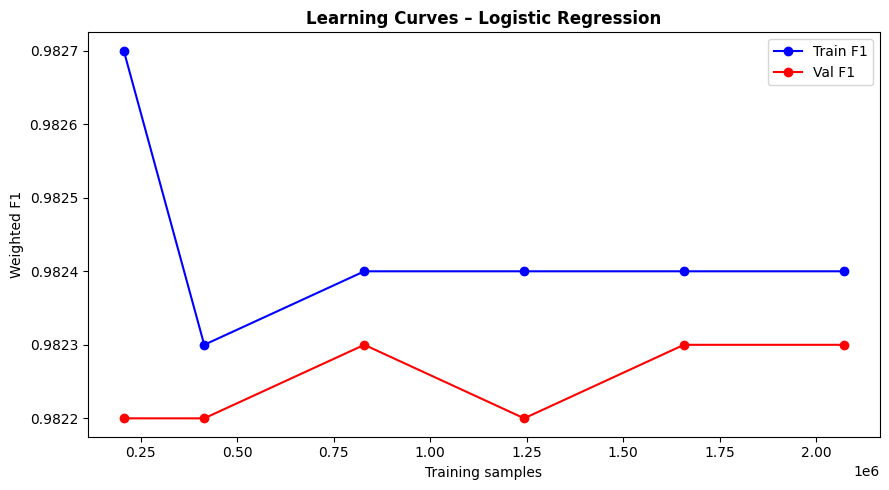

Learning curves saved.


In [9]:
from pyspark.ml.classification import LogisticRegression as LR_LC

print("Learning curves – Logistic Regression:")
train_sizes = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
lc_rows = []

for frac in train_sizes:
    sub_train = train_df.sample(frac, seed=42)
    sub_train.cache(); sub_train.count()

    lr_lc = LR_LC(featuresCol=STD_FEAT, labelCol=LABEL_COL, maxIter=50, regParam=0.01)
    t0    = time.time()
    model = lr_lc.fit(sub_train)

    tr_pred = model.transform(sub_train)
    tr_f1   = mc_f1.evaluate(tr_pred)

    val_df_lc = spark.read.parquet(os.path.join(FEAT_DIR, "val"))
    vl_pred   = model.transform(val_df_lc)
    vl_f1     = mc_f1.evaluate(vl_pred)

    lc_rows.append({'frac': frac, 'n_rows': sub_train.count(),
                    'train_f1': round(tr_f1, 4), 'val_f1': round(vl_f1, 4),
                    'time_s': round(time.time()-t0, 2)})
    sub_train.unpersist()
    print(f"  frac={frac:.1f}  train_F1={tr_f1:.4f}  val_F1={vl_f1:.4f}")

lc_df = pd.DataFrame(lc_rows)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lc_df['n_rows'], lc_df['train_f1'], 'b-o', label='Train F1')
ax.plot(lc_df['n_rows'], lc_df['val_f1'],   'r-o', label='Val F1')
ax.set_xlabel('Training samples')
ax.set_ylabel('Weighted F1')
ax.set_title('Learning Curves – Logistic Regression', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'learning_curves.png'), bbox_inches='tight')
plt.show()

lc_df.to_csv(os.path.join(OUT_DIR, 'learning_curves.csv'), index=False)
print("Learning curves saved.")

## **10. Export Tableau-Ready CSVs**

In [10]:
raw_parq   = spark.read.parquet(os.path.join(BASE_DIR, "project/data/hdfs_parquet"))
event_cols = [f"E{i}" for i in range(1, 30)]
summary_pd = raw_parq.select(event_cols + ['Label', 'total_events']).describe().toPandas()
summary_pd.to_csv(os.path.join(OUT_DIR, 'tableau_data_quality.csv'), index=False)

perf_rows = []
for name, m in test_results.items():
    perf_rows.append({'Model': name, **m})
with open(os.path.join(BASE_DIR, 'project/data/samples/all_results.json')) as fp:
    all_r = json.load(fp)
sk = all_r['sklearn_baseline']
perf_rows.append({'Model':'SK-LR Baseline','AUC_ROC':sk['roc_auc'],
                  'F1':sk['f1_weighted'],'Accuracy':sk['accuracy'],
                  'Precision':sk['f1_weighted'],'Recall':sk['f1_weighted']})
pd.DataFrame(perf_rows).to_csv(os.path.join(OUT_DIR, 'tableau_model_performance.csv'), index=False)

strong_df  = pd.read_csv(os.path.join(OUT_DIR, 'strong_scaling.csv'))
weak_df    = pd.read_csv(os.path.join(OUT_DIR, 'weak_scaling.csv'))
scaling_df = pd.concat([
    strong_df.assign(type='Strong Scaling'),
    weak_df.assign(type='Weak Scaling')
], ignore_index=True)
scaling_df.to_csv(os.path.join(OUT_DIR, 'tableau_scalability.csv'), index=False)

print("Tableau CSVs exported:")
for f in sorted(os.listdir(OUT_DIR)):
    if f.endswith('.csv'):
        sz = os.path.getsize(os.path.join(OUT_DIR, f)) / 1024
        print(f"  {f:45s} {sz:.1f} KB")

26/03/01 11:04:04 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Tableau CSVs exported:
  bootstrap_ci.csv                              0.2 KB
  business_metrics.csv                          0.2 KB
  hdfs_tableau_sample.csv                       16865.1 KB
  learning_curves.csv                           0.2 KB
  model_comparison.csv                          0.2 KB
  pr_data.csv                                   1725.1 KB
  roc_data.csv                                  76.3 KB
  strong_scaling.csv                            0.1 KB
  tableau_data_quality.csv                      1.9 KB
  tableau_model_performance.csv                 0.3 KB
  tableau_scalability.csv                       0.2 KB
  weak_scaling.csv                              0.1 KB


## **11. Final Summary**

In [11]:
print("=" * 65)
print("     HDFS ANOMALY DETECTION – FINAL RESULTS SUMMARY")
print("=" * 65)
print(f"{'Model':<25} {'AUC-ROC':>8} {'F1':>8} {'Accuracy':>9} {'Precision':>10} {'Recall':>8}")
print("-" * 65)
for name, m in test_results.items():
    print(f"{name:<25} {m['AUC_ROC']:>8.4f} {m['F1']:>8.4f} {m['Accuracy']:>9.4f} {m['Precision']:>10.4f} {m['Recall']:>8.4f}")
print("=" * 65)

best_name = max(test_results, key=lambda k: test_results[k]['F1'])
print(f"\nBest model by F1: {best_name}  (F1={test_results[best_name]['F1']})")

with open(os.path.join(OUT_DIR, 'final_test_results.json'), 'w') as fp:
    json.dump({'test_results': test_results}, fp, indent=2)
print("Final results saved.")

test_df.unpersist()
spark.stop()
print("\n✓  Notebook 4 complete.")

26/03/01 11:04:19 WARN BlockManager: Block rdd_76_4 could not be removed as it was not found on disk or in memory
26/03/01 11:04:19 WARN BlockManager: Block rdd_76_3 could not be removed as it was not found on disk or in memory


     HDFS ANOMALY DETECTION – FINAL RESULTS SUMMARY
Model                      AUC-ROC       F1  Accuracy  Precision   Recall
-----------------------------------------------------------------
Logistic Regression         0.9928   0.9649    0.9562     0.9819   0.9562
Random Forest               0.9997   0.9968    0.9969     0.9969   0.9969
GBT                         0.9996   0.9982    0.9982     0.9982   0.9982
Linear SVC                  0.9918   0.9594    0.9481     0.9809   0.9481

Best model by F1: GBT  (F1=0.9982)
Final results saved.

✓  Notebook 4 complete.
